In [1]:
import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/sp500_index.csv')

In [3]:

df["Date"] = pd.to_datetime(df["Date"])

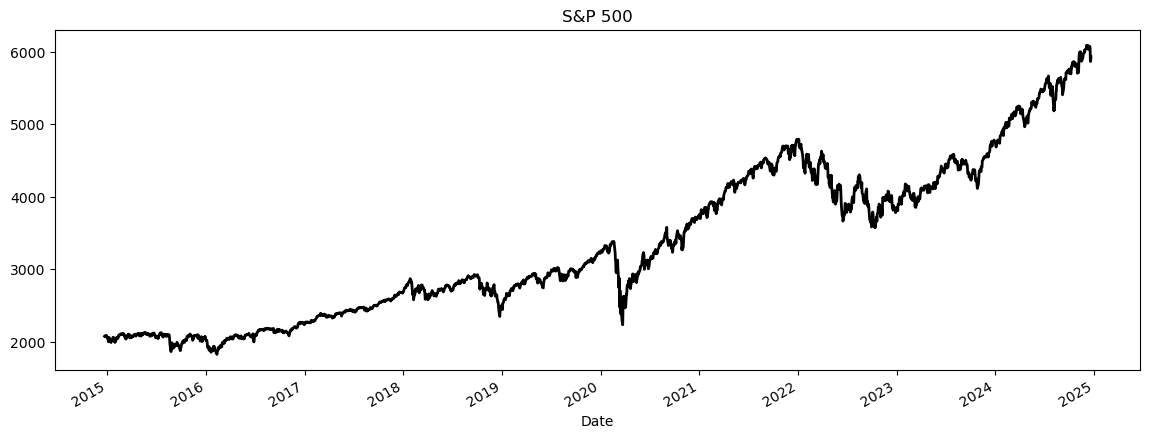

In [4]:

df = df.sort_values("Date")
df = df.set_index("Date")

df["S&P500"].plot(figsize=(14,5), color='black', linewidth=2)
#df["NASDAQCOM"].plot(figsize=(12,5))

plt.title("S&P 500")
plt.show()

In [5]:
returns = np.log(df['S&P500'].shift(-1) /  df['S&P500'] )
data_obs = np.array(returns).reshape(1, -1)[:, -2000:-1000]

In [6]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [0.002, 0.01],  # state 0
    [-0.02, 0.01],  # state 1
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=150, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

KeyboardInterrupt: 

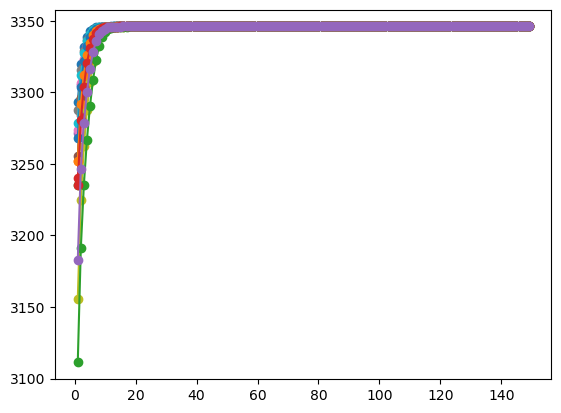

In [ ]:
import matplotlib.pyplot as plt

for i in range(15):
    
    plt.plot(range(1, np.array(err).shape[1]-1), np.array(err)[i, 2:], marker='o')

In [ ]:
print(HMM_list[-1].emission.gauss_params)


[[ 0.00121178  0.00536636]
 [-0.0014707   0.02354254]]


In [ ]:
HMM.emission.gauss_params

array([[ 0.00121178,  0.00536636],
       [-0.0014707 ,  0.02354254]])

In [ ]:
HMM.Viterbi(data_obs)

In [ ]:
print(HMM.best_seqs.shape)

(1, 1000)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimes(dates,prices, hidden_states, n_states):
    
    colors = ['green', 'red']  # un colore per stato
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(dates, prices, color='black', linewidth=2, zorder=2)
    
    # colora le regioni
    i = 0
    while i < len(hidden_states):
        state = int(hidden_states[i])
        j = i
        # trova fino a dove dura questo regime
        while j < len(hidden_states) and hidden_states[j] == state:
            j += 1
        ax.axvspan(dates[i], dates[min(j, len(dates)-1)], 
                   alpha=0.3, color=colors[state], zorder=1)
        i = j
    
    # legenda manuale
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors[k], alpha=0.3, label=f'Regime {k}') 
              for k in range(n_states)]
    ax.legend(handles=legend, loc='upper left')
    
    ax.set_xlabel('time')
    ax.set_ylabel('return')
    plt.tight_layout()
    plt.show()

In [ ]:
df['S&P500'].shape
HMM.best_seqs[0, :].shape

(1000,)

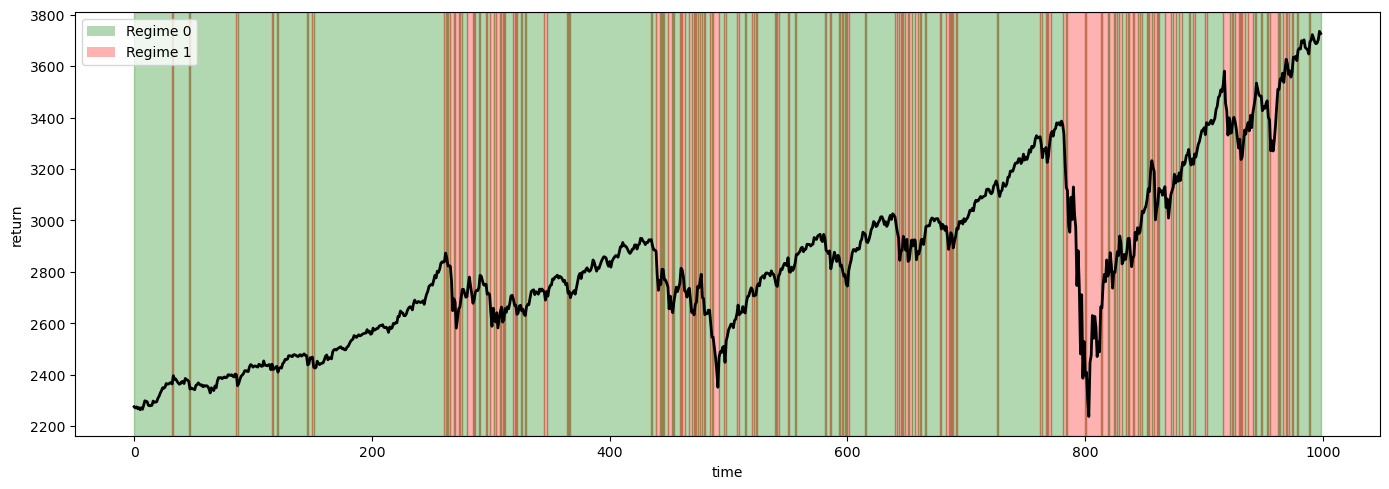

In [ ]:
dates = [i for i in range(999)]

plot_regimes(dates[:], np.array(df['S&P500'])[-2000:-1001], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
data_obs_test=np.array(returns).reshape(1, -1)[:, -1000:]
HMM.Viterbi(data_obs_test)

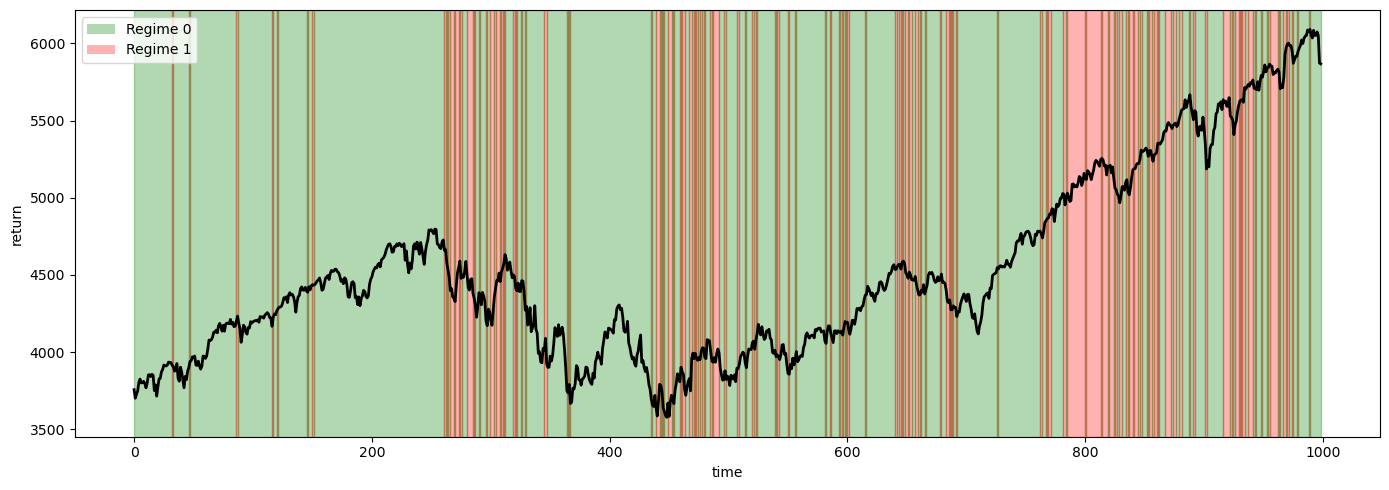

In [ ]:
dates = [i for i in range(999)]

plot_regimes(dates[:], np.array(df['S&P500'])[-1000:-1], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
test_likelihood = HMM.compute_likelihood(data_obs_test)

In [ ]:
test_likelihood

array([3345.99067682])